In [1]:
# Gerekli kütüphaneleri yüklüyoruz
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import shap 

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict 
from imblearn.pipeline import make_pipeline as make_imb_pipeline 
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight 

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN

import warnings
warnings.filterwarnings('ignore') 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# VERİLERİN YÜKLENMESİ VE HAZIRLANMASI
df = pd.read_csv('veri_seti.csv')

df.drop(columns=['Person ID'], inplace=True) 

df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int) 
df['Pulse_Pressure'] = df['Systolic'] - df['Diastolic']  
df['MAP'] = (df['Systolic'] + (2 * df['Diastolic'])) / 3 
df['RPP'] = df['Systolic'] * df['Heart Rate'] 
df.drop(columns=['Blood Pressure'], inplace=True) 

df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal'}) 
bmi_mapping = {
    'Underweight': 0,
    'Normal': 1, 
    'Overweight': 2, 
    'Obese': 3
}
df['BMI_Score'] = df['BMI Category'].map(bmi_mapping) 
df.drop(columns=['BMI Category'], inplace=True) 

df['Sleep_Quality_Ratio'] = df['Quality of Sleep'] / df['Sleep Duration'] 

df['Activity_Intensity'] = df['Daily Steps'] / df['Physical Activity Level'] 

unification_dict = { 
    'Sales Representative': 'Salesperson', 
    'Software Engineer': 'Engineer'        
}
df['Occupation'] = df['Occupation'].replace(unification_dict)
keep_occupations = [ 
    'Doctor', 
    'Nurse', 
    'Engineer', 
    'Lawyer',      
    'Teacher', 
    'Accountant',  
    'Salesperson'  
]
df['Occupation'] = df['Occupation'].apply(lambda x: x if x in keep_occupations else 'Other') 

df['Risk_Factor_Apnea'] = df['Age'] * df['BMI_Score'] 
df['Insomnia_Index'] = df['Stress Level'] / (df['Quality of Sleep'] + 0.1) 

target_col = 'Sleep Disorder'
df[target_col] = df[target_col].fillna('Healthy') 
df[target_col] = df[target_col].replace({'None': 'Healthy', 'Healty': 'Healthy'}) 

print("Veri seti işlendi. Yeni özellikler eklendi.")
print(df.head())

Veri seti işlendi. Yeni özellikler eklendi.
  Gender  Age   Occupation  Sleep Duration  Quality of Sleep  \
0   Male   27     Engineer             6.1                 6   
1   Male   28       Doctor             6.2                 6   
2   Male   28       Doctor             6.2                 6   
3   Male   28  Salesperson             5.9                 4   
4   Male   28  Salesperson             5.9                 4   

   Physical Activity Level  Stress Level  Heart Rate  Daily Steps  \
0                       42             6          77         4200   
1                       60             8          75        10000   
2                       60             8          75        10000   
3                       30             8          85         3000   
4                       30             8          85         3000   

  Sleep Disorder  Systolic  Diastolic  Pulse_Pressure         MAP    RPP  \
0        Healthy       126         83              43   97.333333   9702   
1   

In [3]:
# VERİLERİN EĞİTİM İÇİN HAZIRLANMASI
x = df.drop(columns=[target_col])
y = df[target_col]

le = LabelEncoder()
y = le.fit_transform(y)
print(f"Sınıf Etiketleri: {dict(zip(le.classes_, range(len(le.classes_))))}")

x = pd.get_dummies(x, drop_first=True)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Sınıf Etiketleri: {'Healthy': 0, 'Insomnia': 1, 'Sleep Apnea': 2}


In [4]:
# TÜM KOMBİNASYONLARIN İLE MODELLER OLUŞTURULMASI

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, solver="liblinear",random_state=42),
    "SVC": SVC(class_weight="balanced", probability=True, kernel="rbf", C=50, gamma="scale", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3, weights="distance", metric="minkowski"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", max_depth=None, min_samples_leaf=1, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced_subsample", n_estimators=500, max_depth=15, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=4, min_samples_leaf=2, subsample=0.8, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42, use_label_encoder=False, eval_metric="mlogloss"),
    "LGBM": LGBMClassifier(class_weight="balanced", n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, min_child_samples=5, verbose=-1, random_state=42)
}

samplers = {
    "Dengesiz (Orijinal)": None,
    "SMOTE": SMOTE(random_state=42, sampling_strategy="auto", k_neighbors=2),
    "ADASYN": ADASYN(random_state=42, sampling_strategy="auto", n_neighbors=2),
    "SMOTE + Tomek": SMOTETomek(random_state=42, sampling_strategy="auto"),
    "SMOTE + ENN": SMOTEENN(random_state=42, sampling_strategy="auto")
}

print(f"Toplam {len(samplers)} farklı dengeleme yöntemi ve {len(models)} farklı model deneniyor...")
print("Bu işlem biraz zaman alabilir...")

scoring_metrics = {
        'accuracy' : 'accuracy', 
        'precision' : 'precision_macro', 
        'recall' : 'recall_macro', 
        'f1_macro' : 'f1_macro', 
        'roc_auc' : 'roc_auc_ovr' 
        }

results = []

for sampler_name, sampler in samplers.items():

    print(f"\n{'='*5} Dengeleme Yöntemi: {sampler_name} {'='*5}")
    
    for model_name, model in models.items():
        if sampler:
            pipeline = make_imb_pipeline(StandardScaler(), sampler, model) 
        else:
            pipeline = make_imb_pipeline(StandardScaler(), model) 

        try:
            cv_results = cross_validate(pipeline, x, y, cv=cv, scoring=scoring_metrics, n_jobs=-1) 

            results.append({
                'Dengeleme' : sampler_name,
                'Model' : model_name,
                'Recall' : cv_results['test_recall'].mean(),
                'F1-Score' : cv_results['test_f1_macro'].mean(),
                'ROC-AUC' : cv_results['test_roc_auc'].mean(),
                'Precision' : cv_results['test_precision'].mean(),
                'Accuracy' : cv_results['test_accuracy'].mean()
                
            })
        except Exception as e:
            print(f"Hata oluştu: {model_name} - {sampler_name} : {e}")

print("\nEğitim tamamlandı!")

Toplam 5 farklı dengeleme yöntemi ve 8 farklı model deneniyor...
Bu işlem biraz zaman alabilir...

===== Dengeleme Yöntemi: Dengesiz (Orijinal) =====

===== Dengeleme Yöntemi: SMOTE =====

===== Dengeleme Yöntemi: ADASYN =====

===== Dengeleme Yöntemi: SMOTE + Tomek =====

===== Dengeleme Yöntemi: SMOTE + ENN =====

Eğitim tamamlandı!


In [5]:
# DENGELEME YÖNTEMİ VE MODEL KOMBİNASYONLARININ EN BAŞARILISINA KARAR VERİLMESİ

import pandas as pd
from docx import Document
from docx.shared import Pt, Inches

results_df = pd.DataFrame(results) 

sorted_algos = ['Logistic Regression', 'SVC', 'KNN', 'Decision Tree', 
                'Random Forest', 'Gradient Boosting', 'XGBoost', 'LGBM']

balance_col = 'Dengeleme'
algo_col = 'Model'

doc = Document() 

balancing_methods = results_df[balance_col].unique()

for method in balancing_methods:
    temp = results_df[results_df[balance_col] == method]
    temp = temp.set_index(algo_col).reindex(sorted_algos).reset_index()
    temp = temp.drop(columns=[balance_col])
    
    doc.add_paragraph(f"{method} Yöntemi Sonuçları")
    
    table = doc.add_table(rows=1, cols=len(temp.columns))
    table.style = 'Table Grid'
    
    hdr_cells = table.rows[0].cells
    for i, col in enumerate(temp.columns):
        hdr_cells[i].text = col
        hdr_cells[i].paragraphs[0].paragraph_format.keep_together = True
    
    for _, row in temp.iterrows():
        row_cells = table.add_row().cells
        for i, val in enumerate(row):
            if isinstance(val, float):
                row_cells[i].text = f"{val:.4f}"
            else:
                row_cells[i].text = str(val)
            row_cells[i].paragraphs[0].paragraph_format.keep_together = True
        row_height = Inches(0.25)  
        table.rows[-1].height = row_height
        table.rows[-1].height_rule = 1  

    doc.add_paragraph("")

doc.save("model_sonuclari.docx")
print("Word dosyası kaydedildi: model_sonuclari.docx")

Word dosyası kaydedildi: model_sonuclari.docx


In [5]:
import joblib

# 1. En başarılı olan XGBoost modelini içeren pipeline'ı tüm veriyle eğit
final_pipeline = make_imb_pipeline(StandardScaler(), models["XGBoost"])
final_pipeline.fit(x, y)

# 2. Gereken her şeyi kaydet
joblib.dump(final_pipeline, 'sleep_model.joblib')
joblib.dump(le, 'label_encoder.joblib')
joblib.dump(x.columns.tolist(), 'model_columns.joblib') # Sütun sırası çok önemli!

print("Model dosyaları oluşturuldu: sleep_model.joblib, label_encoder.joblib, model_columns.joblib")

Model dosyaları oluşturuldu: sleep_model.joblib, label_encoder.joblib, model_columns.joblib


<Figure size 700x600 with 0 Axes>

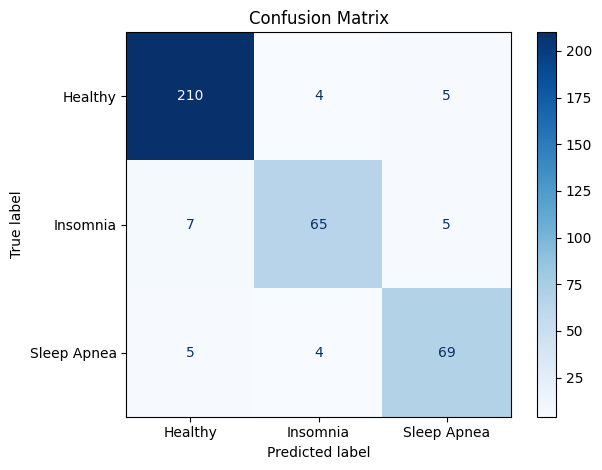

In [ ]:
# CONFUSİON MATRİX

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from sklearn.preprocessing import StandardScaler

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

xgb_pipeline = make_imb_pipeline(
    StandardScaler(),
    xgb_model
)

y_pred = cross_val_predict(
    xgb_pipeline,
    x,
    y,
    cv=cv,
    n_jobs=-1
)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

plt.figure(figsize=(7, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
# MODELİN SONUÇLARININ PYTHON ORTAMINDA GÖRÜNTÜLENMESİ

from sklearn.model_selection import cross_validate
import pandas as pd

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1_macro': 'f1_macro',
    'roc_auc': 'roc_auc_ovr'
}

xgb_pipeline = make_imb_pipeline(
    StandardScaler(),
    xgb_model
)

cv_results = cross_validate(
    xgb_pipeline,
    x,
    y,
    cv=cv,
    scoring=scoring_metrics,
    n_jobs=-1
)

metrics_table = pd.DataFrame([{
    "Dengeleme": "Dengesiz (Orijinal)",
    "Model": "XGBoost",
    "Recall": cv_results["test_recall"].mean(),
    "F1-Score": cv_results["test_f1_macro"].mean(),
    "ROC-AUC": cv_results["test_roc_auc"].mean(),
    "Precision": cv_results["test_precision"].mean(),
    "Accuracy": cv_results["test_accuracy"].mean()
}])

print("\n--- XGBoost Performans Sonuçları (Word ile Birebir) ---")
print(metrics_table)



--- XGBoost Performans Sonuçları (Word ile Birebir) ---
             Dengeleme    Model    Recall  F1-Score  ROC-AUC  Precision  Accuracy
0  Dengesiz (Orijinal)  XGBoost  0.895815  0.898146  0.91887   0.909865  0.919488


PermutationExplainer explainer: 375it [01:18,  4.34it/s]                         


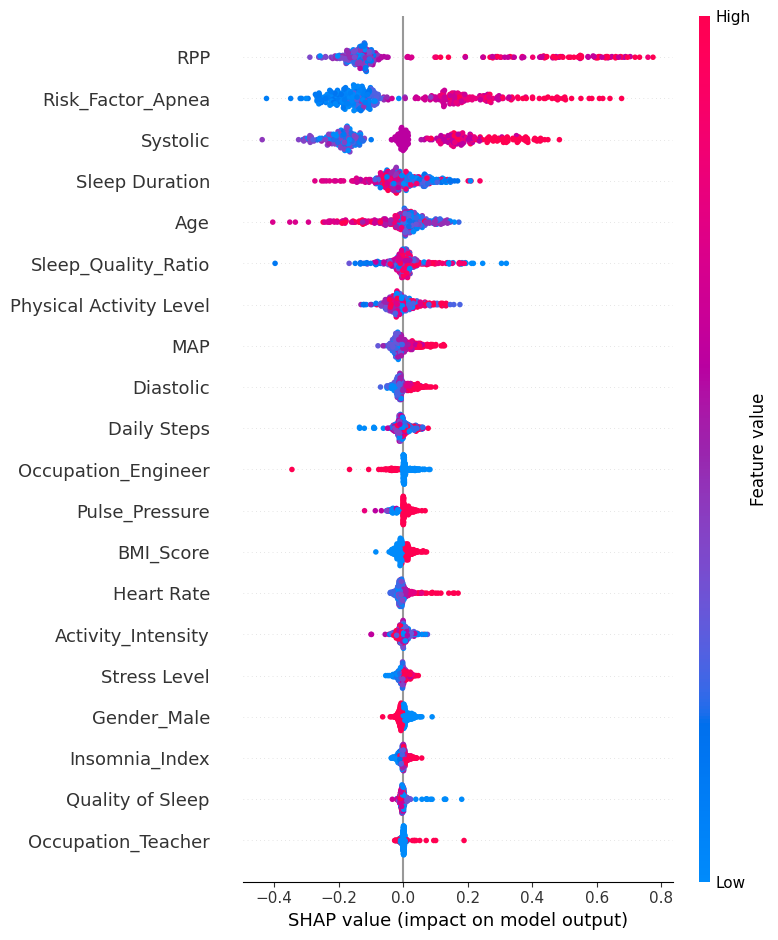

In [ ]:
# SHAP GRAFİĞİ

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import make_pipeline as make_imb_pipeline

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

pipeline = make_imb_pipeline(
    StandardScaler(),
    xgb_model
)

pipeline.fit(x, y)

scaler = pipeline.named_steps['standardscaler']
X_scaled = scaler.transform(x)
X_scaled_df = pd.DataFrame(X_scaled, columns=x.columns)

model = pipeline.named_steps['xgbclassifier']

explainer = shap.Explainer(model.predict, X_scaled_df)

shap_values = explainer(X_scaled_df)

shap.summary_plot(
    shap_values.values,
    X_scaled_df,
    show=True
)


PermutationExplainer explainer: 375it [01:10,  4.91it/s]                         


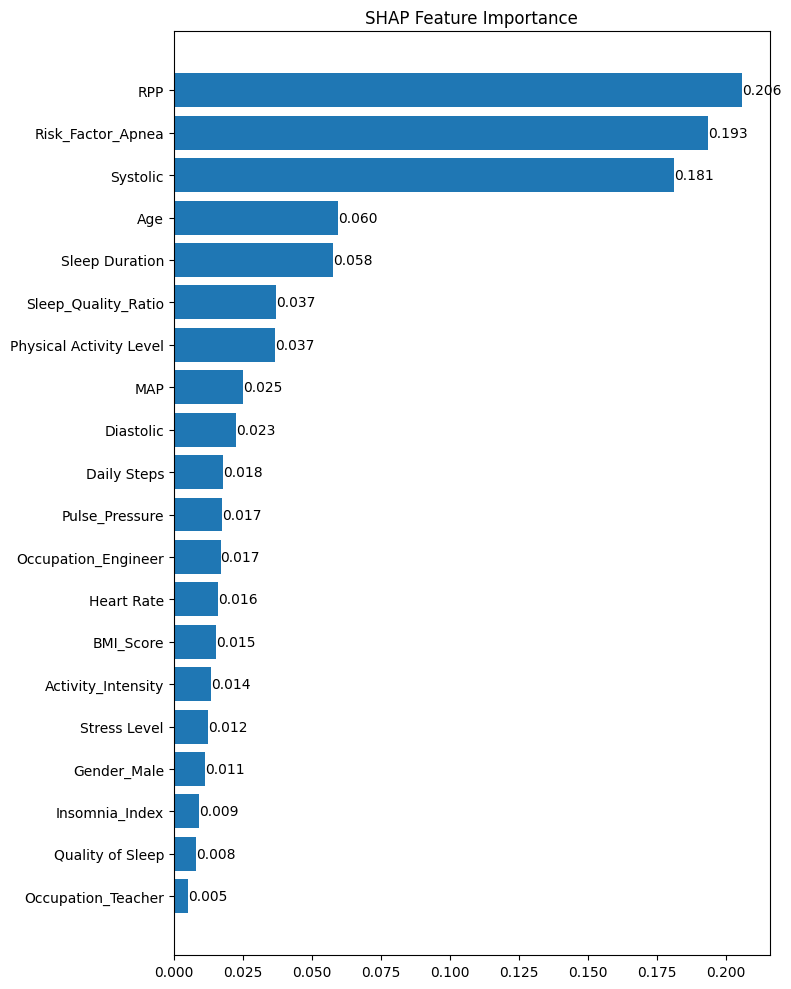

In [ ]:
# SHAP GRAFİĞİ 2

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import make_pipeline as make_imb_pipeline

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

pipeline = make_imb_pipeline(
    StandardScaler(),
    xgb_model
)

pipeline.fit(x, y)

scaler = pipeline.named_steps['standardscaler']
X_scaled = scaler.transform(x)
X_scaled_df = pd.DataFrame(X_scaled, columns=x.columns)

model = pipeline.named_steps['xgbclassifier']

explainer = shap.Explainer(model.predict, X_scaled_df)
shap_values = explainer(X_scaled_df)

mean_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X_scaled_df.columns,
    "Importance": mean_shap
}).sort_values(by="Importance", ascending=False).head(20).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 10))
bars = plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("SHAP Feature Importance")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()


PermutationExplainer explainer: 375it [01:06,  4.56it/s]                         


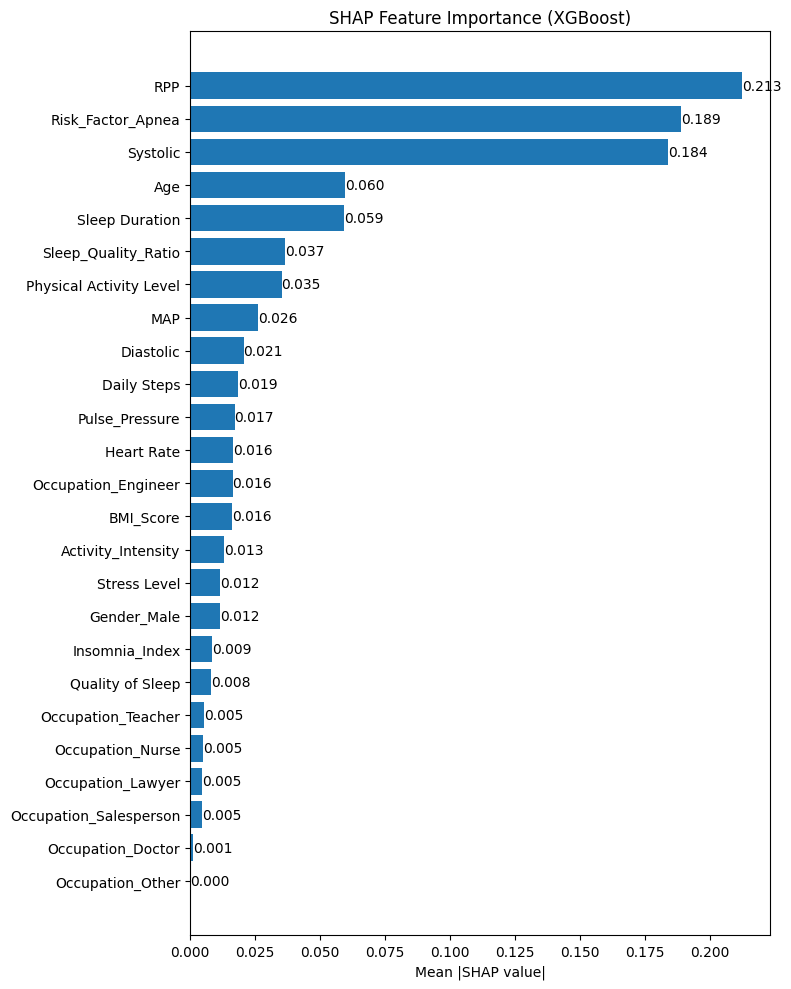

In [ ]:
# SHAP GRAFİĞİ 3 

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import make_pipeline as make_imb_pipeline

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

pipeline = make_imb_pipeline(
    StandardScaler(),
    xgb_model
)

pipeline.fit(x, y)

scaler = pipeline.named_steps['standardscaler']
X_scaled = scaler.transform(x)
X_scaled_df = pd.DataFrame(X_scaled, columns=x.columns)

model = pipeline.named_steps['xgbclassifier']

explainer = shap.Explainer(model.predict, X_scaled_df)
shap_values = explainer(X_scaled_df)

mean_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X_scaled_df.columns,
    "Importance": mean_shap
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 10))
bars = plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Feature Importance (XGBoost)")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()


In [4]:
import joblib

# 'x' senin eğitimde kullandığın (One-hot encoding yapılmış, temizlenmiş) tablo
joblib.dump(x, 'X_full.joblib')

print(f"Tüm veri seti ({len(x)} satır) başarıyla kaydedildi: X_full.joblib")

Tüm veri seti (374 satır) başarıyla kaydedildi: X_full.joblib
